In [12]:
eit_wavelength = 195 #171, 195, 284, or 304 [Angstrom]
eit_time = 'late' #'early' or 'late' (early: around 1 or 4 am; late: around 6 or 7 am)
idx_spectral_image = 120
line_label = 'NeVIII'

In [13]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import datetime as dt
from astropy.io import fits
import matplotlib.patches as patches
from scipy.odr import Model, RealData, ODR
from scipy.interpolate import interp1d
import matplotlib.lines as mlines
import sunpy.map
from astropy.coordinates import SkyCoord
from sunpy.coordinates import frames
import astropy.units as u
from matplotlib.path import Path
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d


import sys
import os
sys.path.append(os.path.abspath('..'))
from utils.data_path import path_data_soho 
from utils.SOHO_aux_functions import *
from utils.calibration_parameters__output import *
from utils.spectroheliogram_functions import *
from utils.solar_rotation_variables import *
from utils.aux_functions import *
from utils.general_variables import *
from utils.NeVIII_rest_wavelength import *


In [14]:
## Create a list with all the headers and another with all data arrays. Units of the data: W/sr/m^2/Angstrom
sumer_header_list, spectral_image_list, spectral_image_unc_list = SUMERraster_get_data_header_and_datauncertainties(sumer_filepath=path_data_soho+'sumer/', sumer_filename_list=filename_list, factor_fullspectrum=factor_fullspectrum, t_exp_sec=t_exp) 

# Chose one spectral image of the raster (index selected at the inputs)
spectral_image = spectral_image_list[idx_spectral_image]
spectral_image_unc = spectral_image_unc_list[idx_spectral_image]
header_sumer = sumer_header_list[idx_spectral_image]

Observatory,Solar and Heliospheric Observatory (SOHO)
Instrument,Extreme-ultraviolet Imaging Telescope (EIT)
Detector,EIT
Measurement,195.0 Angstrom
Wavelength,195.0 Angstrom
Observation Date,1999-11-07 06:36:24
Exposure Time,4.597 s
Dimension,[512. 512.] pix
Coordinate System,helioprojective
Scale,[5.254 5.254] arcsec / pix
Reference Pixel,[255.5 255.5] pix

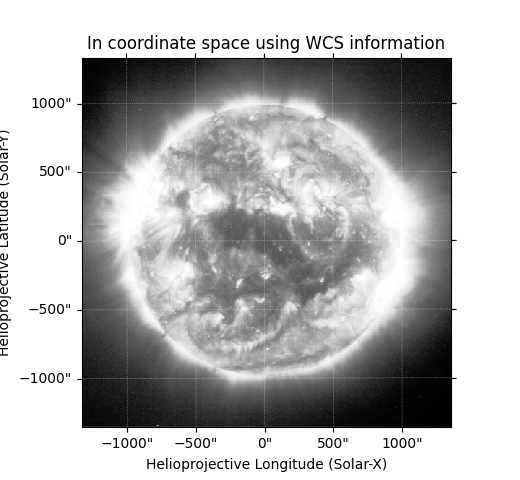
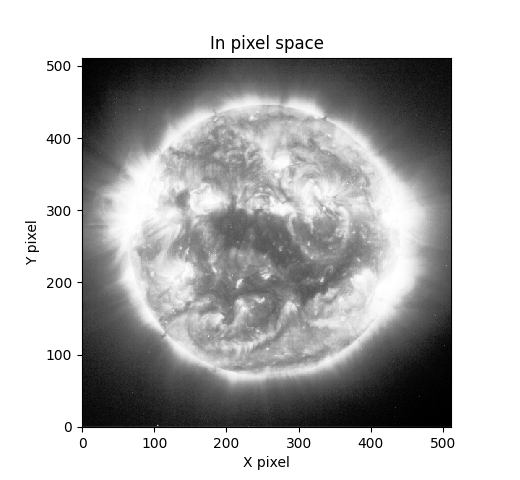
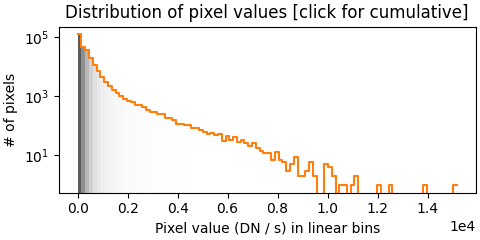
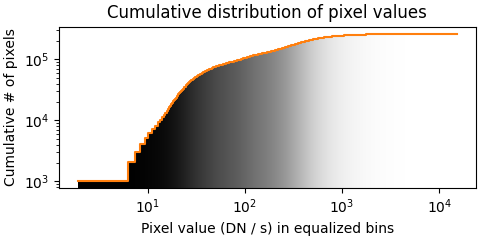

In [15]:
# Import EIT data

# Select the name of the EIT file according to the above inputs
if eit_time=='early':
    if eit_wavelength==171: 
        filename_eit = 'SOHO_EIT_171_19991107T010032_L1.fits'
        vmin_eit, vmax_eit = 3e1, 3e2
    elif eit_wavelength==195: 
        filename_eit = 'SOHO_EIT_195_19991107T042103_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3
    elif eit_wavelength==284: 
        filename_eit = 'SOHO_EIT_284_19991107T011231_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3
    elif eit_wavelength==304: 
        filename_eit = 'SOHO_EIT_304_19991107T013601_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3

elif eit_time=='late':
    if eit_wavelength==171: 
        filename_eit = 'SOHO_EIT_171_19991107T070017_L1.fits'
        vmin_eit, vmax_eit = 3e1, 3e2
    elif eit_wavelength==195: 
        filename_eit = 'SOHO_EIT_195_19991107T063706_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3
    elif eit_wavelength==284: 
        filename_eit = 'SOHO_EIT_284_19991107T070704_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3
    elif eit_wavelength==304: 
        filename_eit = 'SOHO_EIT_304_19991107T073030_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3

# Path of EIT file
filepath_eit = path_data_soho + 'eit/' + filename_eit

# Extract data and header
data_eit = fits.getdata(filepath_eit)[::-1]
header_eit = fits.getheader(filepath_eit)

# Creating a SunPy map object from an image
map_eit = sunpy.map.Map(filepath_eit)
map_eit

In [1]:
# Load the intensity map and uncertainties
intensitymap_loaded_dic = np.load('../data/data_modified/intensity_map_'+line_label+'_interpolated.npz')
intensity_map = intensitymap_loaded_dic['intensity_map'] #2D-array
intensity_map_unc = intensitymap_loaded_dic['intensity_map_unc'] #2D-array
line_center_label = intensitymap_loaded_dic['line_center_label'] 
vmin_sumer, vmax_sumer = intensitymap_loaded_dic['vmin_vmax'] 

# Crop array in latitude 
intensity_map_croplat = intensity_map[slit_top_px:slit_bottom_px+1,:]
intensity_map_unc_croplat = intensity_map_unc[slit_top_px:slit_bottom_px+1,:]


NameError: name 'np' is not defined

In [19]:
from utils.solar_rotation_variables import *
closest_index = closest_index_EIT_SUMER_dic[filename_eit]
closest_time_sumer = closest_time_SUMER_to_EIT_dic[filename_eit]
time_eit = time_EIT_dic[filename_eit]
hour_eit = hour_EIT_dic[filename_eit]
HPlon_rotcomp = HPlon_rotcomp_dic[filename_eit]
HPlon
HPlat
HPlat_croplat = HPlat[slit_top_px:slit_bottom_px+1]


# HP latitude of the top and bottom limits of the SUMER spectra
HPlat_crop_top = HPlat[slit_top_px]
HPlat_crop_bottom = HPlat[slit_bottom_px]


## Find row index in EIT corresponding to these limits
y_px_crop_top = int(np.round(Y__HP_to_pixel(y_HP=HPlat_crop_top, header_eit=header_eit)))
y_px_crop_bottom = int(np.round(Y__HP_to_pixel(y_HP=HPlat_crop_bottom, header_eit=header_eit)))
x_px_crop_left = int(np.round(X__HP_to_pixel(x_HP=HPlon_rotcomp[0], header_eit=header_eit)))
x_px_crop_right = int(np.round(X__HP_to_pixel(x_HP=HPlon_rotcomp[-1], header_eit=header_eit)))


# Crop EIT array
data_eit_crop = data_eit[y_px_crop_top:y_px_crop_bottom, x_px_crop_left:x_px_crop_right]

# Corrected alignment
dx_px = 0
dy_px = -6
data_eit_crop_corrected = data_eit[y_px_crop_top+dy_px : y_px_crop_bottom+dy_px, x_px_crop_left+dx_px : x_px_crop_right+dx_px]


eit_extent = sumer_extent = [HPlon_rotcomp[0], HPlon_rotcomp[-1], HPlat_croplat[-1], HPlat_croplat[0]]


# Define extents properly for EACH image
extent_eit_px = [-0.5, data_eit_crop_corrected.shape[1]-0.5, data_eit_crop_corrected.shape[0]-0.5, -0.5]
extent_sumer_px = [-0.5, intensity_map_croplat.shape[1]-0.5, intensity_map_croplat.shape[0]-0.5, -0.5]


arr_sumer = intensity_map_croplat
arr_eit = data_eit_crop_corrected


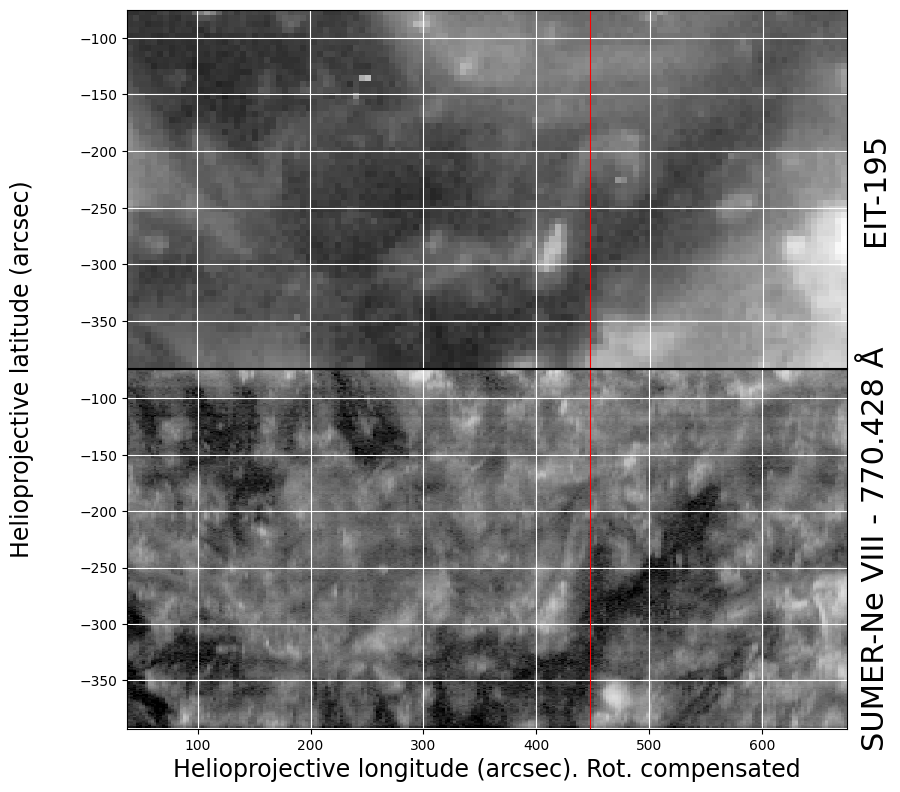

In [20]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(9,8))
label_size = 18
ax[0].imshow(arr_eit, norm=LogNorm(vmin=vmin_eit, vmax=vmax_eit), cmap='Greys_r', extent=eit_extent)
ax[1].pcolormesh(HPlon_rotcomp, HPlat_croplat, arr_sumer, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer))
ax[1].axis('equal') # Ensures equal scaling of axis x and y
#ax[1].set_title(f'SUMER', fontsize=22)
#ax[0].set_title(f'EIT-{header_eit["WAVELNTH"]}', fontsize=22)
ax[1].set_xlabel('Helioprojective longitude (arcsec). Rot. compensated', fontsize=17)
fig.supylabel('Helioprojective latitude (arcsec)', fontsize=17)
ax[0].text(1.02, 0.5, f'EIT-{header_eit["WAVELNTH"]}', fontsize=22,transform=ax[0].transAxes, va='center', ha='left', rotation=90)
ax[1].text(1.02, 0.5, f'SUMER-{line_center_label}', fontsize=22,transform=ax[1].transAxes, va='center', ha='left', rotation=90)
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0, hspace=0)
ax[0].grid(color='white')
ax[1].grid(color='white')
ax[0].axvline(x=HPlon_rotcomp[closest_index], linestyle='-', linewidth=0.8, color='red', label='Slit position during\n EIT image')
ax[1].axvline(x=HPlon_rotcomp[closest_index], linestyle='-', linewidth=0.8, color='red', label='Slit position during\n EIT image')
plt.show(block=False)

In [25]:
header_sumer['CDELT2']

 [astropy.io.fits.verify]


SIMPLE  =                    T / Written by IDL:  Tue Sep 11 23:53:07 2018      
BITPIX  =                  -32 /  IEEE single precision floating point          
NAXIS   =                    2 / Number of data axes                            
NAXIS1  =                  512 /                                                
NAXIS2  =                  360 /                                                
EXTEND  =                    T / FITS data may contain extensions               
DATE    = '2018-09-09'         /  Creation date of FITS header                  
FILENAME= 'sum_19991107_05093080_15415_38.fits' / Name of the FITS file         
SORIG   = 'GenuineIntel GNU/Linux' / Architecture and OS                        
DATASRC = 'Final Distribution (CDROM)' / Data Source                            
TELESCOP= 'SOHO    '           /                                                
INSTRUME= 'SUMER   '           /                                                
DATE_MOD= '2018-09-11T21:53:

In [44]:
filename_eit_list = ['SOHO_EIT_171_19991107T010032_L1.fits', 'SOHO_EIT_195_19991107T042103_L1.fits', 'SOHO_EIT_284_19991107T011231_L1.fits', 'SOHO_EIT_304_19991107T013601_L1.fits', 'SOHO_EIT_171_19991107T070017_L1.fits', 'SOHO_EIT_195_19991107T063706_L1.fits', 'SOHO_EIT_284_19991107T070704_L1.fits', 'SOHO_EIT_304_19991107T073030_L1.fits']

for filename_eit_i in filename_eit_list:
    header_eit_i = fits.getheader(path_data_soho + 'eit/' + filename_eit_i) # Extract header
    label_eit_i = filename_eit_i[9:9+3] + '_' + filename_eit_i[21:21+7]
    print(label_eit_i+':', header_eit_i['CDELT1'], ',', header_eit_i['CDELT2'])

171_T010032: 2.627 , 2.627
195_T042103: 5.254 , 5.254
284_T011231: 2.627 , 2.627
304_T013601: 2.627 , 2.627
171_T070017: 2.627 , 2.627
195_T063706: 5.254 , 5.254
284_T070704: 2.627 , 2.627
304_T073030: 2.627 , 2.627


In [46]:
px_as_EIT195 = 5.254 #[arcsec] 
px_as_EIT171 = 2.627 #[arcsec] 
px_as_SUMER = 1. #approx 1. is the slit width and the pixel scale along the slit
r_as = header_eit['RSUN_OBS'] #978.939298003 / [arcsec] apparent photospheric solar radius    
r_km = header_eit['RSUN_REF']/1000. #695699968 / [m] assumed physical solar radius  

#r_as  --> r_km
#px_as --> px_km??
px_km_EIT195 = px_as_EIT195 * r_km / r_as #km
px_km_EIT171 = px_as_EIT171 * r_km / r_as #km
px_km_SUMER = px_as_SUMER * r_km / r_as #km
#px_km_HRI = 237. #km


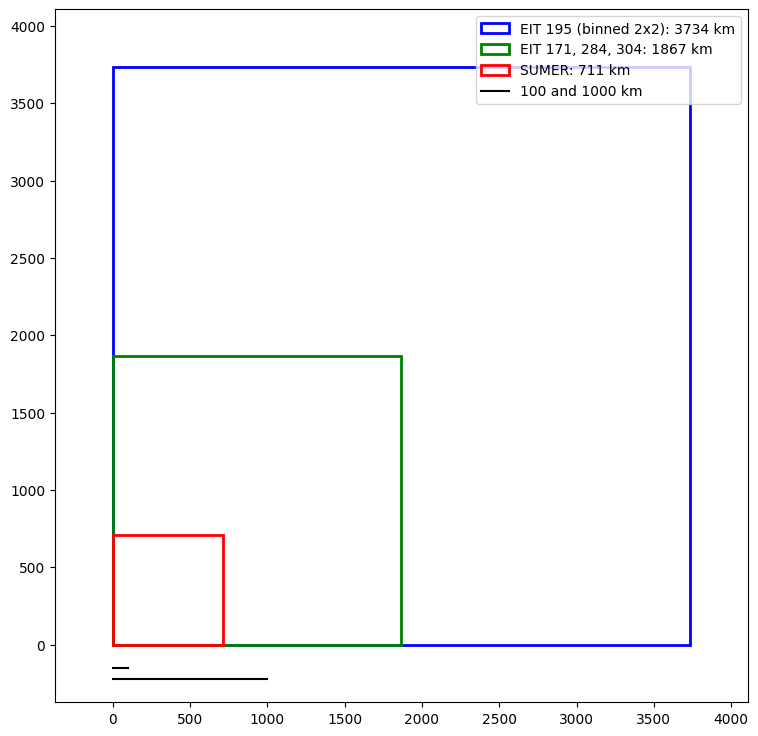

In [90]:
from matplotlib.patches import Rectangle

# side lengths
l1 = px_km_EIT195
l2 = px_km_EIT171
l3 = px_km_SUMER

fig, ax = plt.subplots(figsize=(9,9))
sq1 = Rectangle((0, 0), l1, l1, fill=False, edgecolor='blue', linewidth=2,  label=f"EIT 195 (binned 2x2): {int(np.round(l1))} km")
sq2 = Rectangle((0, 0), l2, l2, fill=False, edgecolor='green', linewidth=2, label=f"EIT 171, 284, 304: {int(np.round(l2))} km")
sq3 = Rectangle((0, 0), l3, l3, fill=False, edgecolor='red', linewidth=2,   label=f"SUMER: {int(np.round(l3))} km")
ax.add_patch(sq1)
ax.add_patch(sq2)
ax.add_patch(sq3)
l_max = np.max([l1,l2,l3])
dl_max = 0.1 * l_max
ax.set_xlim(-dl_max, dl_max+l_max)
ax.set_ylim(-dl_max, dl_max+l_max)
ax.set_aspect('equal')
ax.plot([0,100],[-0.04*l_max, -0.04*l_max], color='black', linewidth=1.5, label='100 and 1000 km')
ax.plot([0,1000],[-0.06*l_max, -0.06*l_max], color='black', linewidth=1.5)
ax.legend(loc="upper right")
plt.show()